# 自注意力（Self-Attention）

自注意力（Self-Attention）是 Transformer 架构的核心，允许序列中的每个位置关注序列中的所有其他位置。

## 原理

给定输入序列 $X \in \mathbb{R}^{n \times d}$，通过三个线性变换得到 Q、K、V：

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

缩放点积注意力计算如下：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

In [1]:
import torch                        # PyTorch 深度学习框架，提供张量运算与自动求导
import torch.nn as nn               # 神经网络模块，包含层、损失函数等常用组件
import torch.nn.functional as F     # 函数式接口，提供 softmax、relu 等无状态操作
import math                         # Python 标准数学库，这里用于计算 sqrt

# 检测是否有可用的 GPU；有则使用 GPU 加速，否则使用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")         # 打印当前使用的计算设备

使用设备: cuda


## 1. 缩放点积注意力（Scaled Dot-Product Attention）

In [ ]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    缩放点积注意力（Scaled Dot-Product Attention）

    原理：用 Query 和 Key 计算相似度分数，再除以 sqrt(d_k) 防止梯度消失，
          经 softmax 归一化后得到注意力权重，最后对 Value 加权求和。

    Args:
        Q    : Query 张量，形状 (batch, heads, seq_len, d_k)
        K    : Key   张量，形状 (batch, heads, seq_len, d_k)
        V    : Value 张量，形状 (batch, heads, seq_len, d_v)
        mask : 可选掩码，形状 (batch, 1, seq_len, seq_len)；
               值为 0 的位置会被屏蔽（填充位或未来位置）
    Returns:
        output      : 注意力加权后的输出，形状 (batch, heads, seq_len, d_v)
        attn_weights: 注意力权重（概率分布），形状 (batch, heads, seq_len, seq_len)
    """
    d_k = Q.size(-1)   # 取 Query 最后一维，即每个头的向量维度 d_k

    # ① 计算 Q 与 K 的点积相似度，再除以 sqrt(d_k) 进行缩放
    #    当 d_k 较大时，点积的方差也大，缩放可以让 softmax 输入更平稳
    #    K.transpose(-2, -1): (B, H, d_k, L) ，matmul 结果: (B, H, L, L)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # ② 如果提供了掩码，将掩码为 0 的位置设为负无穷
    #    经过 softmax 后这些位置的权重趋近于 0，等价于忽略这些位置
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # ③ 对最后一维（Key 维度）做 softmax，得到归一化的注意力权重
    attn_weights = F.softmax(scores, dim=-1)   # 每行之和为 1

    # ④ 用注意力权重对 Value 加权求和，得到最终输出
    #    attn_weights: (B, H, L, L)，V: (B, H, L, d_v) -> output: (B, H, L, d_v)
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

## 2. 单头自注意力层（Single-Head Self-Attention）

In [ ]:
class SelfAttention(nn.Module):
    """
    单头自注意力（Single-Head Self-Attention）

    自注意力的特点：Q、K、V 全部由同一输入 X 线性变换而来，
    因此每个位置能"关注"序列中所有位置（包括自身）的信息。
    """
    def __init__(self, embed_dim):
        """
        Args:
            embed_dim: 输入/输出的特征维度 d_model
        """
        super().__init__()
        self.embed_dim = embed_dim   # 保存特征维度，方便后续使用

        # 三个可学习的线性投影矩阵，将输入 X 映射为 Q、K、V
        # bias=False：遵循原论文不加偏置
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)  # Query 投影
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)  # Key   投影
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)  # Value 投影

        # 输出投影：将注意力结果再做一次线性变换（混合信息）
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, mask=None):
        """
        前向传播

        Args:
            x   : 输入序列，形状 (batch_size, seq_len, embed_dim)
            mask: 可选掩码，形状 (batch_size, 1, seq_len, seq_len)
        Returns:
            out        : 自注意力输出，形状 (batch_size, seq_len, embed_dim)
            attn_weights: 注意力权重，形状 (batch_size, seq_len, seq_len)
        """
        B, L, D = x.shape   # B: batch大小, L: 序列长度, D: 特征维度

        # 通过线性层得到 Q、K、V，再用 unsqueeze(1) 增加"头数"维度
        # 这里只有 1 个头，所以增加的维度大小为 1
        # 形状变化：(B, L, D) -> (B, 1, L, D)
        Q = self.W_q(x).unsqueeze(1)
        K = self.W_k(x).unsqueeze(1)
        V = self.W_v(x).unsqueeze(1)

        # 调用缩放点积注意力函数；out: (B, 1, L, D)，attn_weights: (B, 1, L, L)
        out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # squeeze(1) 去掉多余的"头"维度，恢复 (B, L, D)
        out = out.squeeze(1)

        # 再经过输出投影层做最终线性变换
        out = self.out_proj(out)

        # attn_weights 同样去掉头维度，返回 (B, L, L)
        return out, attn_weights.squeeze(1)

## 3. 多头自注意力层（Multi-Head Self-Attention）

将 $d_{model}$ 维度拆分为 $h$ 个头，每个头独立计算注意力后拼接：

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """
    多头自注意力（Multi-Head Self-Attention, MHSA）

    核心思想：将 embed_dim 均匀拆分为 num_heads 个子空间，
    在每个子空间内分别计算自注意力（称为一个"头"），
    再将所有头的结果拼接后经线性变换输出。
    这样不同的头可以关注不同类型的特征关系。
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        """
        Args:
            embed_dim : 输入/输出特征维度 d_model
            num_heads : 注意力头的数量 h
            dropout   : 输出投影后的 Dropout 概率，防止过拟合
        """
        super().__init__()
        # 断言：embed_dim 必须能被 num_heads 整除，否则无法均等拆分
        assert embed_dim % num_heads == 0, "embed_dim 必须能被 num_heads 整除"

        self.embed_dim = embed_dim          # 总特征维度 d_model
        self.num_heads = num_heads          # 头的数量 h
        self.d_k = embed_dim // num_heads   # 每个头的特征维度 d_k = d_model / h

        # 三个线性投影层，将输入 X 一次性映射到全维度 d_model
        # 之后再通过 split_heads 拆分为多头
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)  # Query 投影
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)  # Key   投影
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)  # Value 投影

        # 输出投影：将多头拼接结果 (d_model) 再次线性映射
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        # Dropout：在输出投影后随机置零，增强泛化能力
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        """
        将全维度张量拆分为多个注意力头

        形状变化：(B, L, D) -> (B, H, L, d_k)
        步骤：
          1. view 将最后一维 D 拆成 (H, d_k)，得到 (B, L, H, d_k)
          2. transpose 把 H 移到第 2 维，得到 (B, H, L, d_k)
        """
        B, L, D = x.shape
        # 重塑：(B, L, D) -> (B, L, num_heads, d_k)
        x = x.view(B, L, self.num_heads, self.d_k)
        # 交换维度：(B, L, H, d_k) -> (B, H, L, d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        """
        前向传播

        Args:
            x   : 输入序列，形状 (batch_size, seq_len, embed_dim)
            mask: 可选掩码，形状 (batch_size, 1, seq_len, seq_len)
        Returns:
            out        : 多头注意力输出，形状 (batch_size, seq_len, embed_dim)
            attn_weights: 各头注意力权重，形状 (batch_size, num_heads, seq_len, seq_len)
        """
        B, L, D = x.shape   # B: 批大小, L: 序列长度, D: 特征维度

        # 1. 线性投影得到全维度 Q、K、V：(B, L, D)
        # 2. split_heads 拆分为多头：(B, H, L, d_k)
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # 对每个头并行计算缩放点积注意力
        # out: (B, H, L, d_k)，attn_weights: (B, H, L, L)
        out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # 将多头结果拼接回原始维度
        # transpose: (B, H, L, d_k) -> (B, L, H, d_k)
        # contiguous: 保证内存连续（transpose 后内存可能不连续）
        # view: (B, L, H, d_k) -> (B, L, D)   D = H * d_k
        out = out.transpose(1, 2).contiguous().view(B, L, D)

        # 经过输出投影 + Dropout
        out = self.dropout(self.out_proj(out))

        # 同时返回注意力权重，方便可视化分析
        return out, attn_weights   # attn_weights: (B, H, L, L)

## 4. Transformer 编码器块（含前馈网络 + 残差连接 + LayerNorm）

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """
    单层 Transformer 编码器块（Encoder Layer）

    完整数据流：
        x
        ├─→ MultiHeadSelfAttention → dropout → + x → LayerNorm  （第一个子层）
        └─→ FeedForward Network   → dropout → + x → LayerNorm  （第二个子层）

    两个子层都使用了"残差连接 + 层归一化"（Add & Norm），
    这有助于缓解梯度消失、加速训练并稳定深层网络。
    """
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        """
        Args:
            embed_dim : 输入特征维度 d_model
            num_heads : 多头注意力的头数
            ffn_dim   : 前馈网络隐层维度（通常为 4 * embed_dim）
            dropout   : Dropout 概率
        """
        super().__init__()

        # 多头自注意力子层
        self.self_attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        # 逐位置前馈网络（Position-wise FFN）
        # 结构：Linear(d_model -> ffn_dim) -> ReLU -> Dropout -> Linear(ffn_dim -> d_model)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),   # 升维：d_model -> ffn_dim（扩展特征空间）
            nn.ReLU(),                        # 非线性激活，引入非线性表达能力
            nn.Dropout(dropout),              # 随机丢弃，防止过拟合
            nn.Linear(ffn_dim, embed_dim),   # 降维：ffn_dim -> d_model（恢复原始维度）
        )

        # 两个层归一化（Layer Normalization）
        # norm1 用于注意力子层之后，norm2 用于 FFN 子层之后
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Dropout：分别在两个子层的残差相加之前应用
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        前向传播

        Args:
            x   : 输入，形状 (batch_size, seq_len, embed_dim)
            mask: 可选掩码，形状 (batch_size, 1, seq_len, seq_len)
        Returns:
            x          : 编码后的输出，形状与输入相同 (B, L, embed_dim)
            attn_weights: 注意力权重，形状 (B, num_heads, L, L)
        """
        # ---- 第一子层：多头自注意力 + 残差连接 + 层归一化 ----
        attn_out, attn_weights = self.self_attn(x, mask)  # 多头自注意力
        # dropout 防止过拟合，然后与原始输入 x 进行残差相加，最后层归一化
        x = self.norm1(x + self.dropout(attn_out))

        # ---- 第二子层：前馈网络 + 残差连接 + 层归一化 ----
        ffn_out = self.ffn(x)                              # 前馈网络
        # 同样做残差连接和层归一化
        x = self.norm2(x + self.dropout(ffn_out))

        # 同时返回注意力权重，用于后续可视化
        return x, attn_weights

## 5. 功能验证

In [6]:
# ==================== 超参数设置 ====================
batch_size = 2    # 批大小：一次同时处理 2 个样本
seq_len    = 6    # 序列长度：每个样本有 6 个 token/位置
embed_dim  = 64   # 特征维度：每个 token 用 64 维向量表示
num_heads  = 4    # 多头注意力的头数：将 64 维拆为 4 头，每头 16 维
ffn_dim    = 128  # 前馈网络隐层维度：通常为 embed_dim 的 2 倍

# ==================== 构造随机输入 ====================
# 生成随机张量模拟一个批次的序列输入，形状 (batch_size, seq_len, embed_dim)
# 实际场景中这里是词嵌入（word embedding）的输出
x = torch.randn(batch_size, seq_len, embed_dim).to(device)
print(f"输入形状: {x.shape}")   # 期望输出：torch.Size([2, 6, 64])

# ==================== 测试：单头自注意力 ====================
single_attn = SelfAttention(embed_dim).to(device)         # 实例化单头自注意力层
out_single, w_single = single_attn(x)                     # 前向传播，得到输出和注意力权重
print(f"单头自注意力输出: {out_single.shape}")             # 期望：(2, 6, 64) — 形状与输入相同
print(f"注意力权重形状:   {w_single.shape}")               # 期望：(2, 6, 6) — 每个位置对所有位置的权重

# ==================== 测试：多头自注意力 ====================
mhsa = MultiHeadSelfAttention(embed_dim, num_heads).to(device)   # 实例化多头自注意力层
out_mhsa, w_mhsa = mhsa(x)                                       # 前向传播
print(f"多头自注意力输出: {out_mhsa.shape}")   # 期望：(2, 6, 64) — 输出形状不变
print(f"多头注意力权重:   {w_mhsa.shape}")     # 期望：(2, 4, 6, 6) — 每个头都有一组注意力权重

# ==================== 测试：完整编码器块 ====================
encoder_block = TransformerEncoderBlock(embed_dim, num_heads, ffn_dim).to(device)  # 实例化编码器块
out_enc, w_enc = encoder_block(x)                                                   # 前向传播
print(f"编码器块输出:     {out_enc.shape}")    # 期望：(2, 6, 64) — 编码后形状与输入一致（保持维度）

输入形状: torch.Size([2, 6, 64])
单头自注意力输出: torch.Size([2, 6, 64])
注意力权重形状:   torch.Size([2, 6, 6])
多头自注意力输出: torch.Size([2, 6, 64])
多头注意力权重:   torch.Size([2, 4, 6, 6])
编码器块输出:     torch.Size([2, 6, 64])


## 6. 注意力权重可视化

/tmp/ipython-input-2945385538.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


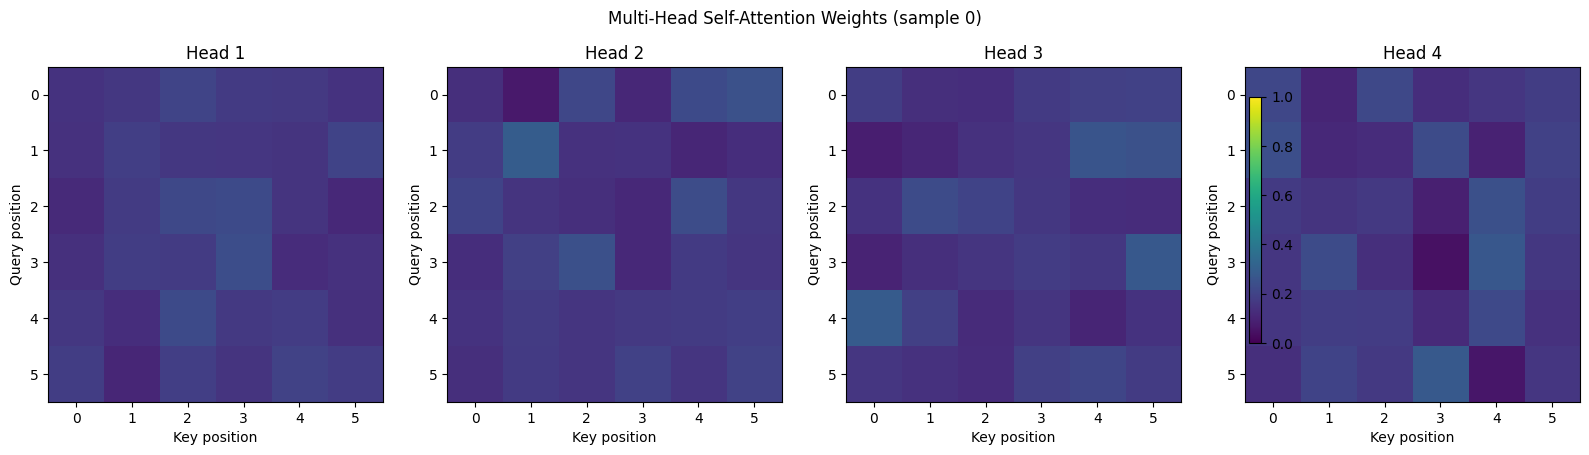

In [7]:
import matplotlib.pyplot as plt   # 绘图库，用于生成热力图和折线图
import matplotlib

# 设置全局字体为无衬线字体，避免中文乱码（如需中文标签可改为 'SimHei' 等）
matplotlib.rcParams['font.family'] = 'sans-serif'
# 解决 matplotlib 负号"-"显示为方框的问题
plt.rcParams['axes.unicode_minus'] = False

# ==================== 获取注意力权重 ====================
# w_enc 形状：(batch_size, num_heads, seq_len, seq_len)
# 取第一个样本（索引 0）的所有头，并移到 CPU、脱离计算图
attn = w_enc[0].detach().cpu()   # 形状：(num_heads, seq_len, seq_len)

# ==================== 绘制热力图 ====================
# 每个头单独画一张子图，共 num_heads 张
fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 4))

for h, ax in enumerate(axes):
    # imshow 将矩阵可视化为热力图
    # cmap='viridis': 深紫到黄的配色，数值越大颜色越亮
    # vmin/vmax: 固定色彩范围为 [0, 1]，便于不同头之间比较
    im = ax.imshow(attn[h].numpy(), cmap='viridis', vmin=0, vmax=1)

    ax.set_title(f"Head {h+1}")            # 子图标题，显示第几个头
    ax.set_xlabel("Key position")          # x 轴：被关注的位置（Key）
    ax.set_ylabel("Query position")        # y 轴：发起关注的位置（Query）

    # 设置刻度为 0, 1, ..., seq_len-1，对应序列中每个位置
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))

# 在所有子图右侧添加统一的颜色条，shrink 控制颜色条的相对高度
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)

# 总标题，y>1 将其放在所有子图上方
plt.suptitle("Multi-Head Self-Attention Weights (sample 0)", y=1.02)
plt.tight_layout()   # 自动调整子图间距，避免重叠
plt.show()           # 显示图形

## 7. 简单序列分类任务训练示例

构建一个 2 层 Transformer 编码器 + 全局平均池化 + 分类头，对随机生成的序列进行二分类训练。

Epoch   5 | Loss: 0.0374 | Acc: 99.2%
Epoch  10 | Loss: 0.0009 | Acc: 100.0%
Epoch  15 | Loss: 0.0004 | Acc: 100.0%
Epoch  20 | Loss: 0.0003 | Acc: 100.0%


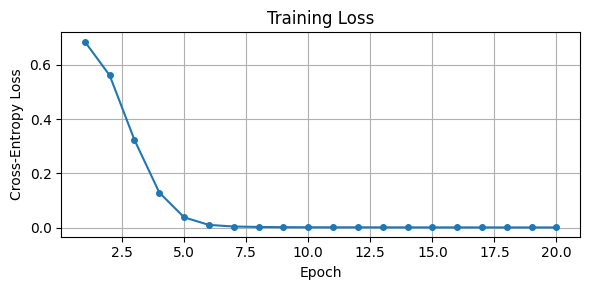

In [8]:
class TransformerClassifier(nn.Module):
    """
    基于多层 Transformer 编码器的序列分类模型

    整体结构：
        输入序列 X (B, L, D)
            ↓
        N 层 TransformerEncoderBlock（堆叠多层以增强表达能力）
            ↓
        全局平均池化 mean(dim=1)  →  (B, D)   （将序列压缩为单个向量）
            ↓
        全连接分类头  Linear(D, num_classes)
            ↓
        输出 logits (B, num_classes)
    """
    def __init__(self, embed_dim, num_heads, ffn_dim, num_layers, num_classes, dropout=0.1):
        """
        Args:
            embed_dim  : 特征维度 d_model
            num_heads  : 每层多头注意力的头数
            ffn_dim    : 前馈网络隐层维度
            num_layers : Transformer 编码器层数（堆叠深度）
            num_classes: 分类类别数
            dropout    : Dropout 概率
        """
        super().__init__()

        # 使用 ModuleList 堆叠 num_layers 个编码器块
        # ModuleList 会将所有子模块注册到模型参数中，以便优化器更新
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)   # 循环创建 num_layers 个独立的编码器块
        ])

        # 分类头：将 d_model 维向量映射到 num_classes 个类别的得分（logits）
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, mask=None):
        """
        前向传播

        Args:
            x   : 输入序列，形状 (batch_size, seq_len, embed_dim)
            mask: 可选掩码
        Returns:
            logits: 分类得分，形状 (batch_size, num_classes)
        """
        # 依次通过每一层 Transformer 编码器块
        # 每层输出作为下一层的输入（深层特征提取）
        for layer in self.layers:
            x, _ = layer(x, mask)   # 忽略返回的注意力权重（用 _ 接收）

        # 全局平均池化：对序列长度维度取平均
        # (B, L, D) -> (B, D)   将变长序列压缩为固定大小的向量
        x = x.mean(dim=1)

        # 将池化向量送入分类头，得到各类别的原始得分（logits）
        return self.classifier(x)


# ==================== 超参数 ====================
torch.manual_seed(42)   # 固定随机种子，确保结果可复现

embed_dim   = 64    # 特征维度
num_heads   = 4     # 注意力头数
ffn_dim     = 128   # 前馈网络隐层维度
num_layers  = 2     # 编码器层数
num_classes = 2     # 二分类任务：类别 0 或 1
seq_len     = 10    # 每个样本的序列长度
n_samples   = 512   # 训练数据总量
epochs      = 20    # 训练轮数
lr          = 1e-3  # Adam 学习率

# ==================== 构造数据集 ====================
# 随机生成 n_samples 条序列，每条长度 seq_len，每 token 维度 embed_dim
X_data = torch.randn(n_samples, seq_len, embed_dim)

# 根据整条序列的全局均值来确定标签：
#   均值 > 0 → 标签 1（正样本），否则 → 标签 0（负样本）
# dim=(1,2) 表示同时对序列维度和特征维度取平均，得到标量
y_data = (X_data.mean(dim=(1, 2)) > 0).long()

# 将数据封装为 TensorDataset，方便 DataLoader 按批次读取
dataset = torch.utils.data.TensorDataset(X_data, y_data)

# DataLoader：每批 32 个样本，随机打乱顺序（shuffle=True）防止过拟合
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# ==================== 模型、优化器、损失函数 ====================
# 实例化分类模型并移到目标设备（CPU/GPU）
model = TransformerClassifier(embed_dim, num_heads, ffn_dim, num_layers, num_classes).to(device)

# Adam 优化器：自适应学习率，综合了动量和二阶矩估计，收敛快
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# 交叉熵损失：适用于多分类任务（包含 softmax），这里用于二分类
criterion = nn.CrossEntropyLoss()

# ==================== 训练循环 ====================
loss_history = []   # 记录每轮平均损失，用于绘制曲线

for epoch in range(1, epochs + 1):
    model.train()   # 切换到训练模式（启用 Dropout 和 BatchNorm 的训练行为）

    total_loss = 0.0   # 累计本轮所有批次的总损失
    correct    = 0     # 累计本轮预测正确的样本数

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)   # 将当前批次的数据移到计算设备

        logits = model(xb)                        # 前向传播，得到原始分类得分

        loss = criterion(logits, yb)              # 计算当前批次的交叉熵损失

        optimizer.zero_grad()  # 清空上一步的梯度（必须在 backward 前调用）
        loss.backward()        # 反向传播：计算各参数的梯度
        optimizer.step()       # 梯度下降：用 Adam 更新所有参数

        # 累加损失（乘以批大小，便于后面除以总样本数得到平均值）
        total_loss += loss.item() * xb.size(0)
        # 累加正确预测数（取 logits 最大值的索引作为预测类别）
        correct    += (logits.argmax(1) == yb).sum().item()

    avg_loss = total_loss / n_samples   # 当前 epoch 的平均损失
    acc      = correct / n_samples      # 当前 epoch 的分类准确率
    loss_history.append(avg_loss)       # 记录损失，用于后续绘图

    # 每 5 轮输出一次训练状态
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Acc: {acc*100:.1f}%")

# ==================== 绘制训练损失曲线 ====================
plt.figure(figsize=(6, 3))
# 绘制损失随 epoch 变化的折线图，marker 标记每个数据点
plt.plot(range(1, epochs + 1), loss_history, marker='o', markersize=4)
plt.xlabel("Epoch")                      # x 轴：训练轮数
plt.ylabel("Cross-Entropy Loss")         # y 轴：交叉熵损失值
plt.title("Training Loss")               # 图标题
plt.grid(True)                           # 显示网格，方便读数
plt.tight_layout()                       # 自动调整布局，防止标签被截断
plt.show()                               # 渲染并展示图形